# Mental Health in Tech — Exploratory Data Analysis

**Dataset:** OSMI Mental Health in Tech Survey (2014 & 2016)  
**Objective:** Understand patterns in mental health treatment-seeking behavior among tech workers  
**Target Variable:** Whether a person has sought mental health treatment

---
## Table of Contents
1. Import Libraries
2. Load Datasets
3. Dataset Overview
4. Missing Values Analysis
5. Target Variable Analysis
6. Age Analysis
7. Gender Analysis
8. Geographic Analysis
9. Workplace Factors Analysis
10. Correlation Analysis
11. 2014 vs 2016 Comparison
12. Key Findings Summary

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette('Set2')
sns.set_style('whitegrid')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Datasets

In [2]:
df14 = pd.read_csv(r"C:\Users\hp\Desktop\Mental health in tech\survey.csv")
df16 = pd.read_csv(r"C:\Users\hp\Desktop\Mental health in tech\mental-heath-in-tech-2016_20161114.csv")

print(f'2014 Survey: {df14.shape[0]} rows, {df14.shape[1]} columns')
print(f'2016 Survey: {df16.shape[0]} rows, {df16.shape[1]} columns')

2014 Survey: 1259 rows, 27 columns
2016 Survey: 1433 rows, 63 columns


## 3. Dataset Overview

In [3]:
print('=== 2014 Dataset — First 5 rows ===')
df14.head()

=== 2014 Dataset — First 5 rows ===


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [4]:
print('=== 2014 — Data Types & Basic Stats ===')
df14.describe(include='all')

=== 2014 — Data Types & Basic Stats ===


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
count,1259,1.259000e+03,1259,1259,744,1241,1259,1259,995,1259,...,1259,1259,1259,1259,1259,1259,1259,1259,1259,164
unique,1246,NaN,49,48,45,2,2,2,4,6,...,5,3,3,3,3,3,3,3,2,160
top,2014-08-27 12:44:51,NaN,Male,United States,CA,No,No,Yes,Sometimes,6-25,...,Don't know,No,No,Some of them,Yes,No,Maybe,Don't know,No,* Small family business - YMMV.
freq,2,NaN,615,751,138,1095,767,637,465,290,...,563,490,925,774,516,1008,557,576,1075,5
mean,NaN,7.942815e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,2.818299e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,-1.726000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2.700000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,3.100000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,3.600000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print('=== 2016 Dataset — First 5 rows ===')
df16.head()

=== 2016 Dataset — First 5 rows ===


,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Lead,Sometimes
4,0,6-25,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes


## 4. Missing Values Analysis

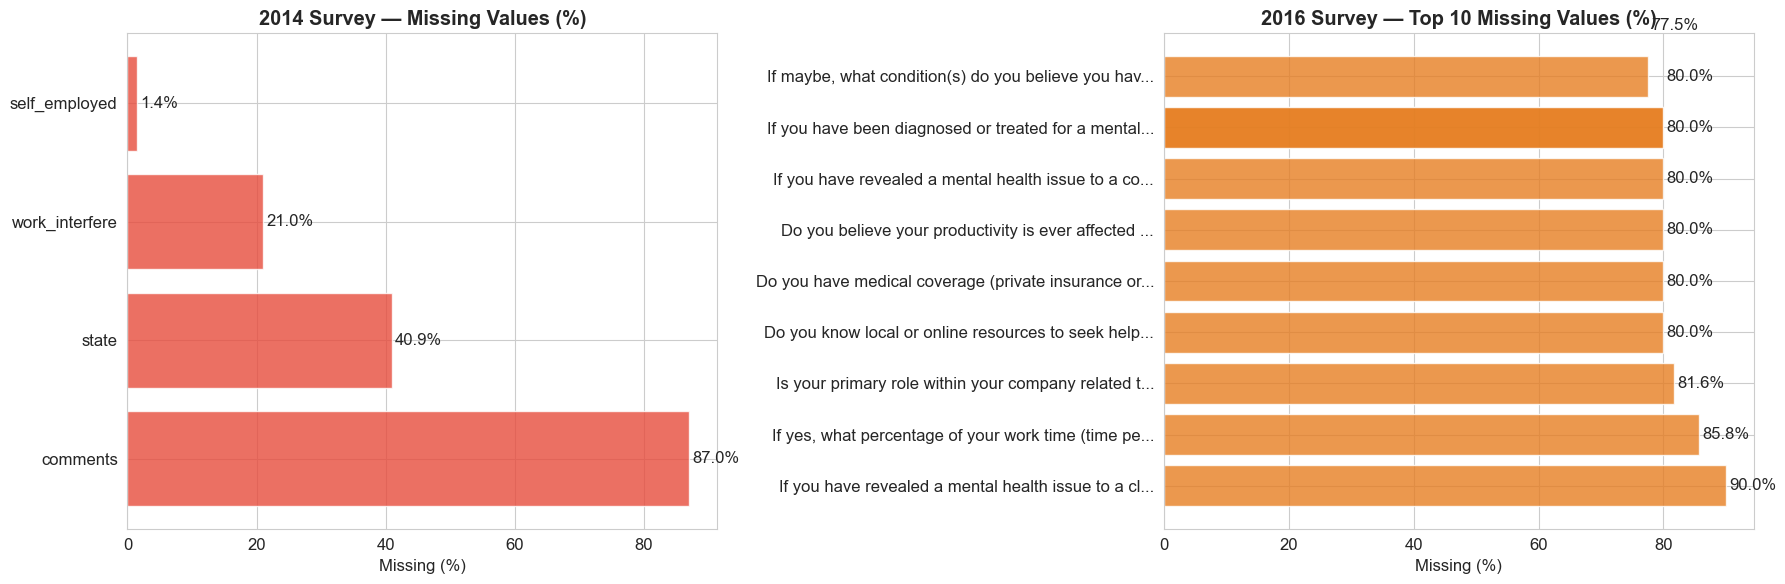

Key observations:
  state: 515 missing → non-US respondents (expected)
  work_interfere: 264 missing → likely no mental health issue
  comments: 1095 missing → optional free-text field


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

missing14 = (df14.isnull().sum() / len(df14) * 100).sort_values(ascending=False)
missing14 = missing14[missing14 > 0]
axes[0].barh(missing14.index, missing14.values, color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('2014 Survey — Missing Values (%)', fontweight='bold')
for i, v in enumerate(missing14.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center')

missing16 = (df16.isnull().sum() / len(df16) * 100).sort_values(ascending=False).head(10)
missing16 = missing16[missing16 > 0]
short_labels = [col[:50] + '...' if len(col) > 50 else col for col in missing16.index]
axes[1].barh(short_labels, missing16.values, color='#e67e22', alpha=0.8)
axes[1].set_xlabel('Missing (%)')
axes[1].set_title('2016 Survey — Top 10 Missing Values (%)', fontweight='bold')
for i, v in enumerate(missing16.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

print('Key observations:')
print(f'  state: {df14["state"].isnull().sum()} missing → non-US respondents (expected)')
print(f'  work_interfere: {df14["work_interfere"].isnull().sum()} missing → likely no mental health issue')
print(f'  comments: {df14["comments"].isnull().sum()} missing → optional free-text field')

## 5. Target Variable Analysis

- **2014:** `treatment` column (Yes/No)
- **2016:** `Have you ever sought treatment for a mental health issue from a mental health professional?` (1/0)

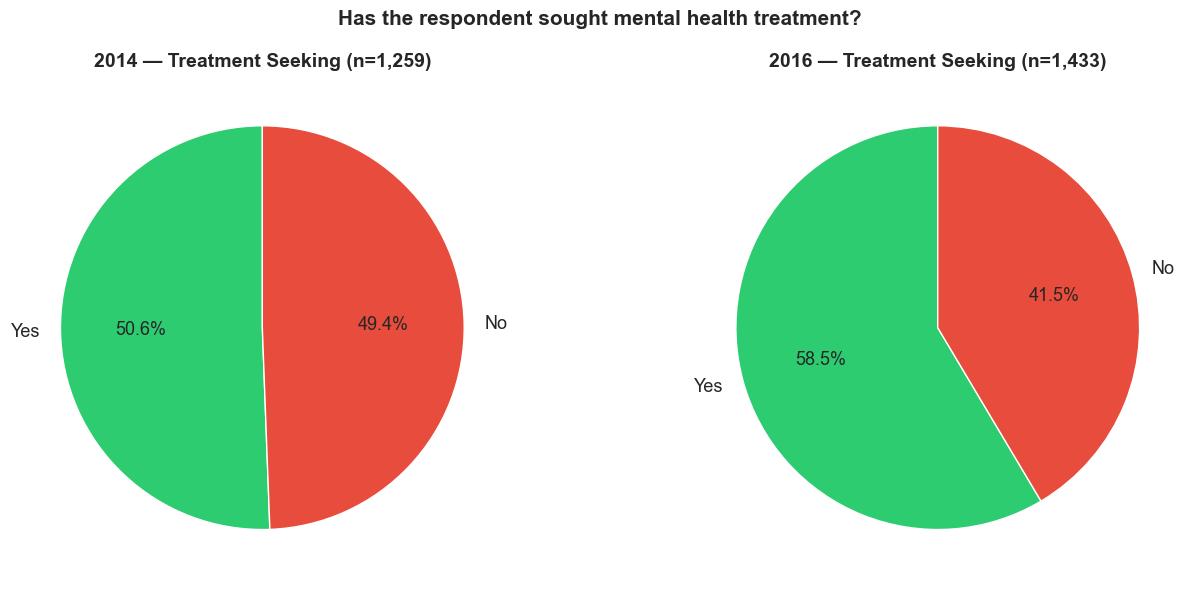

2014 treatment rate: 50.6%  →  Nearly balanced classes
2016 treatment rate: 58.5%  →  Slight class imbalance
Trend: treatment seeking INCREASED by +8.0pp from 2014 to 2016


In [7]:
target_col_16 = 'Have you ever sought treatment for a mental health issue from a mental health professional?'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#2ecc71', '#e74c3c']

counts14 = df14['treatment'].value_counts()
axes[0].pie(counts14.values, labels=counts14.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 13})
axes[0].set_title('2014 — Treatment Seeking (n=1,259)', fontweight='bold', fontsize=14)

counts16 = df16[target_col_16].map({1: 'Yes', 0: 'No'}).value_counts()
axes[1].pie(counts16.values, labels=counts16.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 13})
axes[1].set_title('2016 — Treatment Seeking (n=1,433)', fontweight='bold', fontsize=14)

plt.suptitle('Has the respondent sought mental health treatment?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

rate14 = (df14['treatment'] == 'Yes').mean() * 100
rate16 = (df16[target_col_16] == 1).mean() * 100
print(f'2014 treatment rate: {rate14:.1f}%  →  Nearly balanced classes')
print(f'2016 treatment rate: {rate16:.1f}%  →  Slight class imbalance')
print(f'Trend: treatment seeking INCREASED by {rate16 - rate14:+.1f}pp from 2014 to 2016')

## 6. Age Analysis

In [8]:
print('=== Age Outliers in 2014 ===')
print('Values < 15:', sorted(df14[df14['Age'] < 15]['Age'].tolist()))
print('Values > 80:', sorted(df14[df14['Age'] > 80]['Age'].tolist()))
print(f'\nRaw: min={df14["Age"].min()}, max={df14["Age"].max()}')

df14_ca = df14[(df14['Age'] >= 15) & (df14['Age'] <= 80)].copy()
df16_ca = df16[(df16['What is your age?'] >= 15) & (df16['What is your age?'] <= 80)].copy()
print(f'After cleaning → 2014: {len(df14_ca)} rows, 2016: {len(df16_ca)} rows')

=== Age Outliers in 2014 ===
Values < 15: [-1726, -29, -1, 5, 8, 11]
Values > 80: [329, 99999999999]

Raw: min=-1726, max=99999999999
After cleaning → 2014: 1251 rows, 2016: 1430 rows


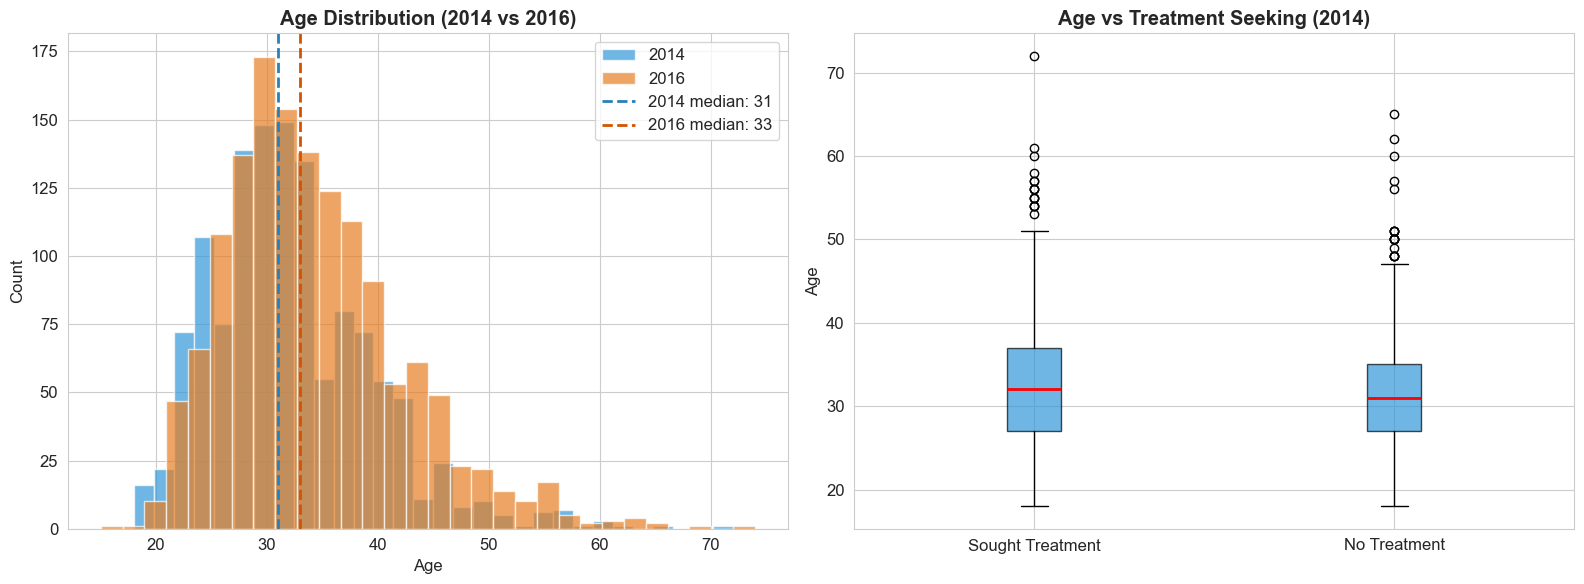

           count       mean       std   min   25%   50%   75%   max
treatment                                                          
No         619.0  31.534733  6.966401  18.0  27.0  31.0  35.0  65.0
Yes        632.0  32.607595  7.558193  18.0  27.0  32.0  37.0  72.0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df14_ca['Age'], bins=30, color='#3498db', alpha=0.7, label='2014', edgecolor='white')
axes[0].hist(df16_ca['What is your age?'], bins=30, color='#e67e22', alpha=0.7, label='2016', edgecolor='white')
axes[0].axvline(df14_ca['Age'].median(), color='#2980b9', linestyle='--', linewidth=2,
                label=f'2014 median: {df14_ca["Age"].median():.0f}')
axes[0].axvline(df16_ca['What is your age?'].median(), color='#d35400', linestyle='--', linewidth=2,
                label=f'2016 median: {df16_ca["What is your age?"].median():.0f}')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution (2014 vs 2016)', fontweight='bold')
axes[0].legend()

age_yes = df14_ca[df14_ca['treatment'] == 'Yes']['Age'].tolist()
age_no  = df14_ca[df14_ca['treatment'] == 'No']['Age'].tolist()
axes[1].boxplot([age_yes, age_no], labels=['Sought Treatment', 'No Treatment'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Age')
axes[1].set_title('Age vs Treatment Seeking (2014)', fontweight='bold')

plt.tight_layout()
plt.show()

print(df14_ca.groupby('treatment')['Age'].describe())

## 7. Gender Analysis

In [10]:
print('Raw gender values in 2014 (top 20):')
print(df14['Gender'].value_counts().head(20))
print(f'\nTotal unique values: {df14["Gender"].nunique()}')

Raw gender values in 2014 (top 20):
Gender
Male                        615
male                        206
Female                      121
M                           116
female                       62
F                            38
m                            34
f                            15
Make                          4
Male                          3
Woman                         3
Cis Male                      2
Man                           2
Female (trans)                2
Female                        2
Trans woman                   1
msle                          1
male leaning androgynous      1
Neuter                        1
cis male                      1
Name: count, dtype: int64

Total unique values: 49


In [11]:
def standardize_gender(gender):
    if pd.isna(gender):
        return 'Other'
    g = str(gender).lower().strip()
    male_kw = ['male', 'm', 'man', 'cis male', 'cis man', 'maile', 'mal',
                'make', 'mail', 'malr', 'msle', 'male-ish', 'male (cis)']
    female_kw = ['female', 'f', 'woman', 'cis female', 'cis woman',
                  'femake', 'femail', 'femmale']
    if g in male_kw:
        return 'Male'
    elif g in female_kw:
        return 'Female'
    else:
        return 'Other'

df14['gender_clean'] = df14['Gender'].apply(standardize_gender)
df16['gender_clean'] = df16['What is your gender?'].apply(standardize_gender)

print('After standardization (2014):', df14['gender_clean'].value_counts().to_dict())
print('After standardization (2016):', df16['gender_clean'].value_counts().to_dict())

After standardization (2014): {'Male': 991, 'Female': 245, 'Other': 23}
After standardization (2016): {'Male': 1051, 'Female': 330, 'Other': 52}


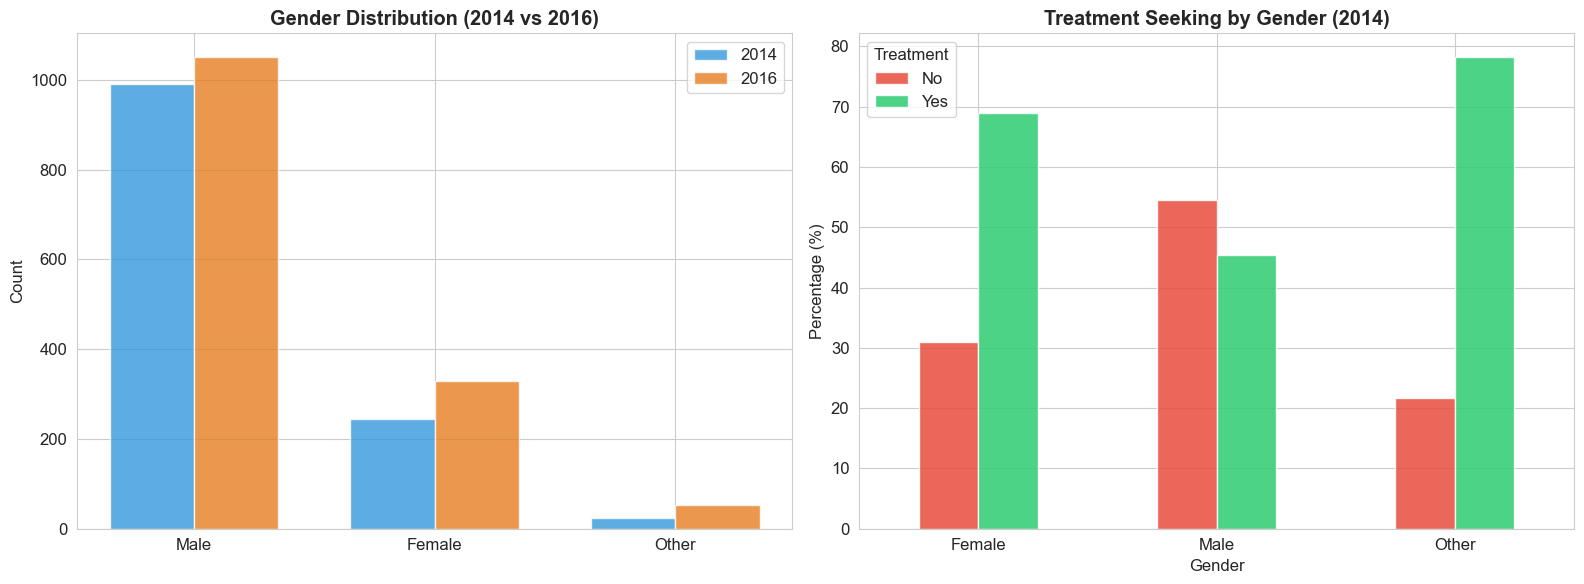

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

gender_counts14 = df14['gender_clean'].value_counts()
gender_counts16 = df16['gender_clean'].value_counts()
x = np.arange(len(gender_counts14.index))
width = 0.35

axes[0].bar(x - width/2, gender_counts14.values, width, label='2014', color='#3498db', alpha=0.8)
axes[0].bar(x + width/2, [gender_counts16.get(g, 0) for g in gender_counts14.index],
            width, label='2016', color='#e67e22', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(gender_counts14.index)
axes[0].set_title('Gender Distribution (2014 vs 2016)', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend()

gender_treatment = df14.groupby(['gender_clean', 'treatment']).size().unstack(fill_value=0)
gender_treatment_pct = gender_treatment.div(gender_treatment.sum(axis=1), axis=0) * 100
gender_treatment_pct.plot(kind='bar', ax=axes[1],
                           color=['#e74c3c', '#2ecc71'], alpha=0.85, edgecolor='white')
axes[1].set_title('Treatment Seeking by Gender (2014)', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Gender')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Treatment')

plt.tight_layout()
plt.show()

## 8. Geographic Analysis

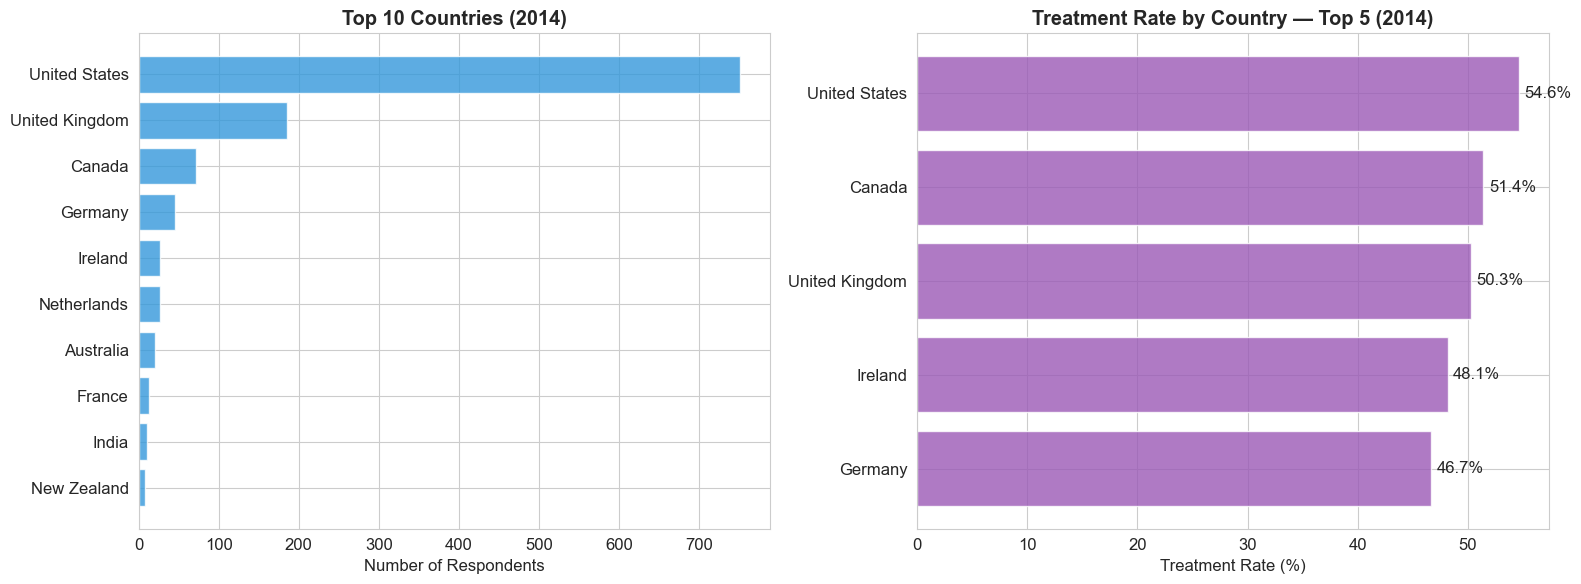

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_countries14 = df14['Country'].value_counts().head(10)
axes[0].barh(top_countries14.index[::-1], top_countries14.values[::-1], color='#3498db', alpha=0.8)
axes[0].set_title('Top 10 Countries (2014)', fontweight='bold')
axes[0].set_xlabel('Number of Respondents')

top5 = top_countries14.head(5).index.tolist()
country_treatment = df14[df14['Country'].isin(top5)].groupby('Country')['treatment'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=True)
axes[1].barh(country_treatment.index, country_treatment.values, color='#9b59b6', alpha=0.8)
axes[1].set_title('Treatment Rate by Country — Top 5 (2014)', fontweight='bold')
axes[1].set_xlabel('Treatment Rate (%)')
for i, v in enumerate(country_treatment.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

## 9. Workplace Factors Analysis

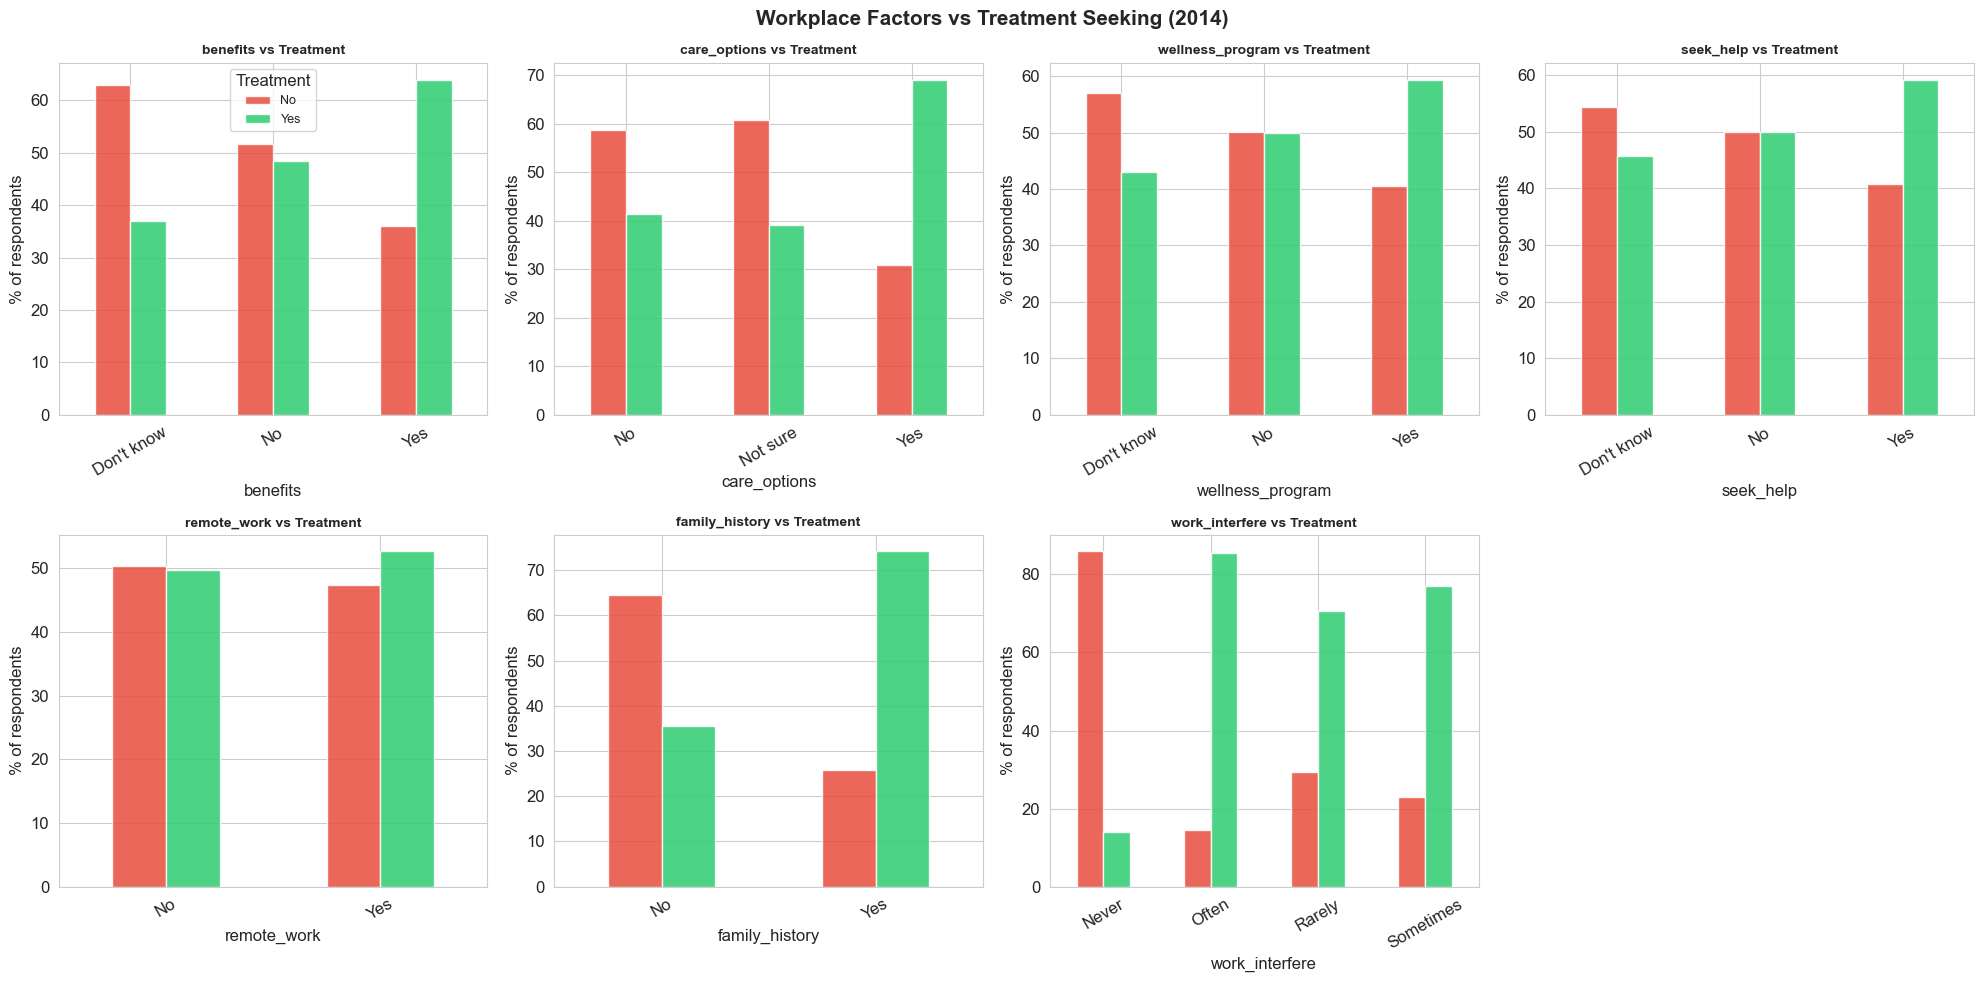

In [14]:
workplace_cols = ['benefits', 'care_options', 'wellness_program', 'seek_help',
                  'remote_work', 'family_history', 'work_interfere']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(workplace_cols):
    ct = df14.groupby([col, 'treatment']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=axes[i], color=['#e74c3c', '#2ecc71'],
                alpha=0.85, edgecolor='white', legend=(i == 0))
    axes[i].set_title(f'{col} vs Treatment', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('% of respondents')
    axes[i].tick_params(axis='x', rotation=30)
    if i == 0:
        axes[i].legend(title='Treatment', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Workplace Factors vs Treatment Seeking (2014)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

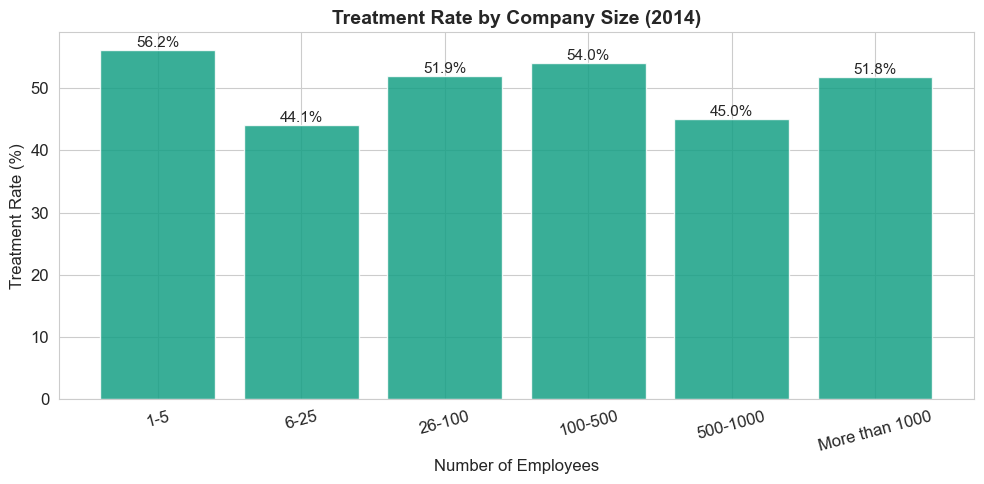

In [15]:
size_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
df14_size = df14[df14['no_employees'].isin(size_order)].copy()
df14_size['no_employees'] = pd.Categorical(df14_size['no_employees'], categories=size_order, ordered=True)
size_treatment = df14_size.groupby('no_employees', observed=True)['treatment'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

plt.figure(figsize=(10, 5))
plt.bar(range(len(size_treatment)), size_treatment.values, color='#16a085', alpha=0.85, edgecolor='white')
plt.xticks(range(len(size_treatment)), size_treatment.index, rotation=15)
plt.title('Treatment Rate by Company Size (2014)', fontweight='bold', fontsize=14)
plt.xlabel('Number of Employees')
plt.ylabel('Treatment Rate (%)')
for i, v in enumerate(size_treatment.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 10. Correlation Analysis

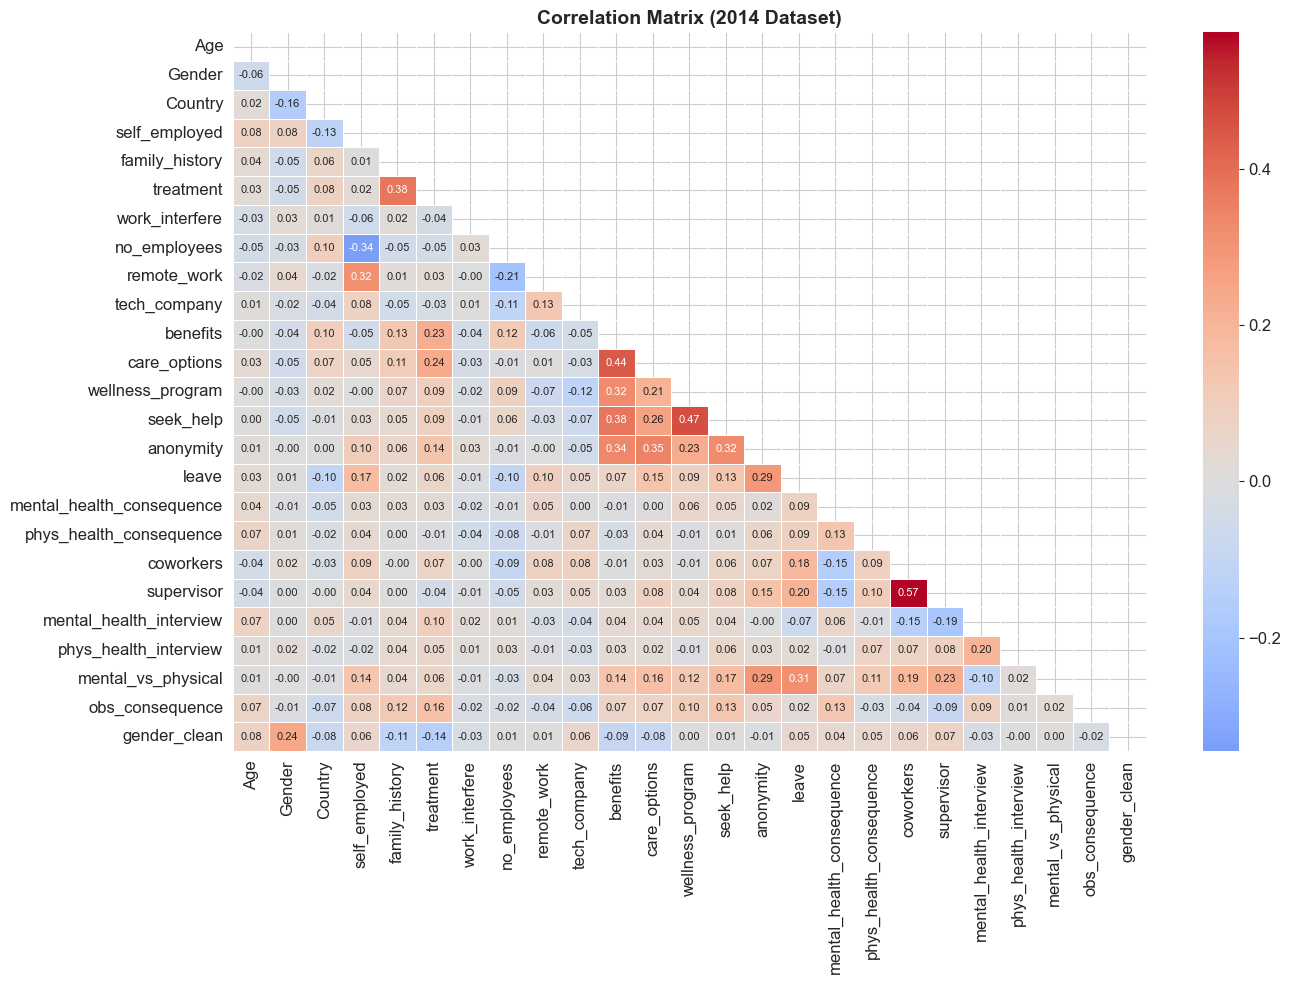

In [16]:
df14_corr = df14.drop(columns=['Timestamp', 'state', 'comments']).copy()
df14_corr['gender_clean'] = df14['gender_clean']

le = LabelEncoder()
for col in df14_corr.select_dtypes(include='object').columns:
    df14_corr[col] = df14_corr[col].fillna('Unknown')
    df14_corr[col] = le.fit_transform(df14_corr[col].astype(str))

df14_corr = df14_corr.fillna(df14_corr.median())

plt.figure(figsize=(14, 10))
corr_matrix = df14_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix (2014 Dataset)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

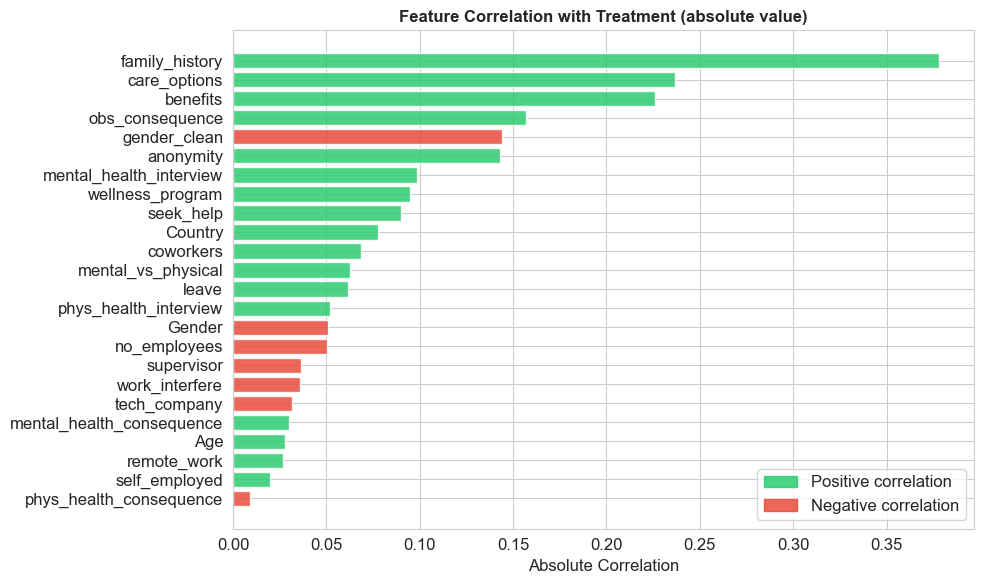

Top 5 features correlated with treatment:
  family_history: 0.378 (positive)
  care_options: 0.237 (positive)
  benefits: 0.226 (positive)
  obs_consequence: 0.157 (positive)
  gender_clean: 0.144 (negative)


In [17]:
treatment_corr = corr_matrix['treatment'].drop('treatment').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors_fc = ['#e74c3c' if corr_matrix['treatment'][feat] < 0 else '#2ecc71'
             for feat in treatment_corr.index]
plt.barh(treatment_corr.index[::-1], treatment_corr.values[::-1],
         color=colors_fc[::-1], alpha=0.85)
plt.title('Feature Correlation with Treatment (absolute value)', fontweight='bold', fontsize=12)
plt.xlabel('Absolute Correlation')
red_patch = mpatches.Patch(color='#e74c3c', alpha=0.85, label='Negative correlation')
green_patch = mpatches.Patch(color='#2ecc71', alpha=0.85, label='Positive correlation')
plt.legend(handles=[green_patch, red_patch])
plt.tight_layout()
plt.show()

print('Top 5 features correlated with treatment:')
for feat, val in treatment_corr.head(5).items():
    direction = 'positive' if corr_matrix['treatment'][feat] > 0 else 'negative'
    print(f'  {feat}: {val:.3f} ({direction})')

## 11. 2014 vs 2016 Comparison

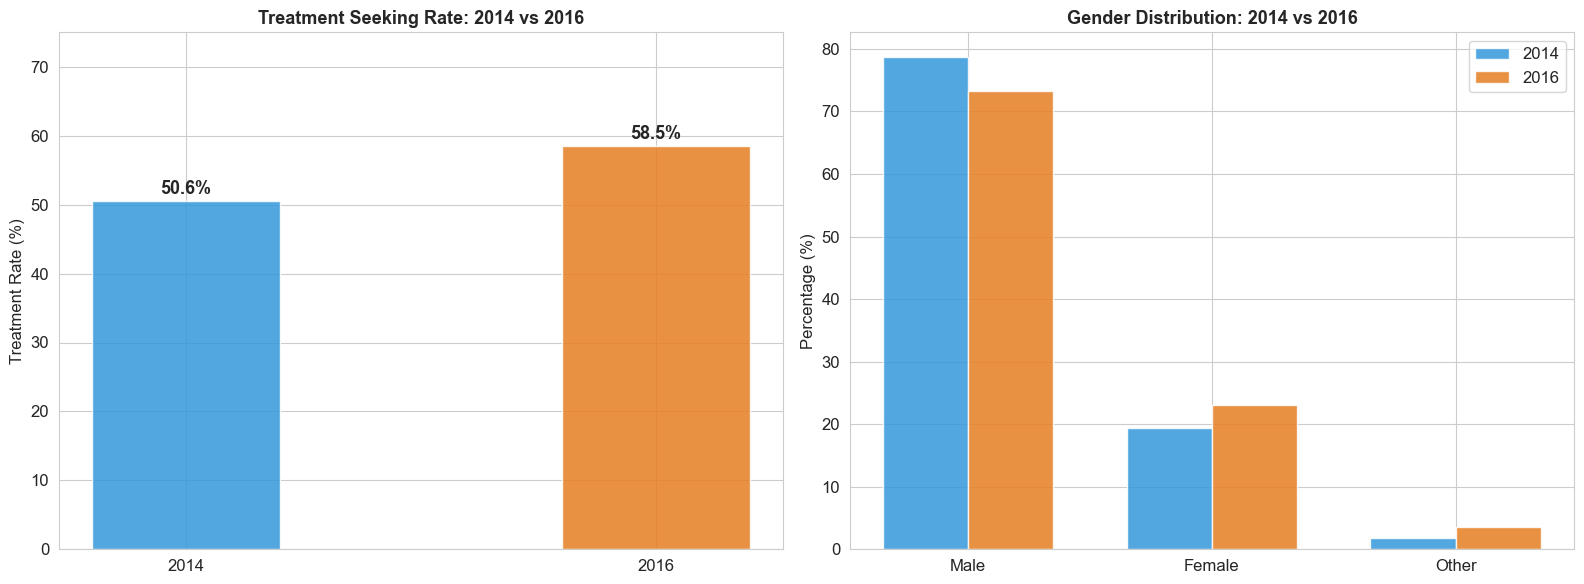

Treatment rate 2014: 50.6%
Treatment rate 2016: 58.5%
Change: +8.0 percentage points


In [18]:
treatment_rate14 = (df14['treatment'] == 'Yes').mean() * 100
treatment_rate16 = (df16[target_col_16] == 1).mean() * 100
gender14_pct = df14['gender_clean'].value_counts(normalize=True) * 100
gender16_pct = df16['gender_clean'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].bar(['2014', '2016'], [treatment_rate14, treatment_rate16],
                   color=['#3498db', '#e67e22'], alpha=0.85, width=0.4, edgecolor='white')
axes[0].set_ylim(0, 75)
axes[0].set_title('Treatment Seeking Rate: 2014 vs 2016', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Treatment Rate (%)')
for bar, val in zip(bars, [treatment_rate14, treatment_rate16]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

genders = ['Male', 'Female', 'Other']
x = np.arange(3)
width = 0.35
vals14 = [gender14_pct.get(g, 0) for g in genders]
vals16 = [gender16_pct.get(g, 0) for g in genders]
axes[1].bar(x - width/2, vals14, width, label='2014', color='#3498db', alpha=0.85, edgecolor='white')
axes[1].bar(x + width/2, vals16, width, label='2016', color='#e67e22', alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(genders)
axes[1].set_title('Gender Distribution: 2014 vs 2016', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Percentage (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Treatment rate 2014: {treatment_rate14:.1f}%')
print(f'Treatment rate 2016: {treatment_rate16:.1f}%')
print(f'Change: {treatment_rate16 - treatment_rate14:+.1f} percentage points')

<a id='12'></a>
## 12. Key Findings Summary

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Dataset is well-balanced (~50/50) | No need for SMOTE; accuracy is valid metric |
| 2 | Age outliers exist (-1726, 99999999999) | Must clean before modeling |
| 3 | Gender has 49+ unique values | Standardize to Male/Female/Other |
| 4 | `family_history` strongly correlates with treatment | Important feature for model |
| 5 | `work_interfere` is a key predictor | 85% treatment rate when "Often" |
| 6 | Mental health benefits at work matter | People with benefits seek help more |
| 7 | US dominates (~60% of respondents) | Model may have geographic bias |
| 8 | Treatment-seeking increased 2014→2016 | Positive social trend in tech |
| 9 | `comments` column has 87% missing | Will be dropped |
| 10 | Female respondents seek treatment more | Gender is a meaningful predictor |